# Nurse Rostering — Metaheuristic Solver (Genetic Algorithm)

This notebook develops a Genetic Algorithm (GA) for the nurse rostering problem, together with the roster evaluator used to score candidate solutions. The same evaluator scores solutions produced by both the exact (Integer Linear Programming) and the metaheuristic (GA) methods, so the two approaches are compared on an identical objective and constraint set.

Benchmark: Nurse Rostering Benchmark Instances 1–24 (Curtois & Qu). See `data/README.md`.

## 1. Roster evaluation

The evaluator is implemented independently of the exact model, so that neither method is scored by its own objective code. For any candidate roster it returns:

| Key | Meaning |
|---|---|
| `penalty` | soft objective: under-/over-cover penalties plus unmet shift-on and violated shift-off requests |
| `hard` | violation amount for each hard constraint H1–H9 (0 when satisfied) |
| `feasible` | `True` if and only if every hard violation is 0 |

**Roster representation.** A NumPy integer array of shape `(n_nurses, n_days)`, following the convention documented in `rostering_common.py`: `0` denotes a day off and `k` denotes the k-th shift type in `Instance.shift_ids` (1-based).

**Reference values (Instance 1).** The empty roster has penalty `7137`; a roster in which one nurse works the shift on days 2 and 3 has penalty `6933`. These are used to validate the evaluator.

In [11]:
import numpy as np
from rostering_common import load_instance, Instance   # shared instance parser

### 1.1 Evaluator

Each constraint is checked by a small, self-contained block so that it can be read and tested in isolation.

In [12]:
def _runs(mask):
    """Yield (start, length) of every maximal run of True in a 1-D boolean list."""
    i, n = 0, len(mask)
    while i < n:
        if mask[i]:
            j = i
            while j < n and mask[j]:
                j += 1
            yield i, j - i
            i = j
        else:
            i += 1


def evaluate(roster: np.ndarray, inst: Instance) -> dict:
    """Score one roster against one instance.

    Returns {'penalty': float, 'hard': {'H1'..'H9': amount}, 'feasible': bool}.
    The penalty is the soft objective, in the same units as the ILP objective.
    """
    n_nurses, n_days = roster.shape
    shift_of = {k + 1: sid for k, sid in enumerate(inst.shift_ids)}   # roster value -> shift id

    # ---------- Soft objective ----------
    penalty = 0.0

    # S3 cover: for each (day, shift) count the nurses working it, pay under- and over-cover
    for (d, sid), (req, w_under, w_over) in inst.cover.items():
        val = inst.shift_ids.index(sid) + 1
        worked = int(np.count_nonzero(roster[:, d] == val))
        penalty += w_under * max(0, req - worked) + w_over * max(0, worked - req)

    # S1 shift-on requests: pay the weight when the requested shift is not worked
    for nurse, d, sid, w in inst.on_requests:
        i = inst.nurse_ids.index(nurse)
        if roster[i, d] != inst.shift_ids.index(sid) + 1:
            penalty += w

    # S2 shift-off requests: pay the weight when the avoided shift is worked
    for nurse, d, sid, w in inst.off_requests:
        i = inst.nurse_ids.index(nurse)
        if roster[i, d] == inst.shift_ids.index(sid) + 1:
            penalty += w

    # ---------- Hard constraints H1..H9 (violation amount, 0 = satisfied) ----------
    hard = {f"H{k}": 0.0 for k in range(1, 10)}

    for i, nurse in enumerate(inst.nurse_ids):
        row = roster[i]
        work = [row[d] != 0 for d in range(n_days)]

        # H1 at most one shift per day: guaranteed by the encoding (one integer per cell)

        # H2 forbidden succession: the shift on day d+1 must not be forbidden after day d
        for d in range(n_days - 1):
            if row[d] != 0 and row[d + 1] != 0:
                if shift_of[row[d + 1]] in inst.forbidden_next[shift_of[row[d]]]:
                    hard["H2"] += 1

        # H3 maximum shifts per type
        for k, sid in enumerate(inst.shift_ids, start=1):
            cnt = int(np.count_nonzero(row == k))
            limit = inst.max_shifts[nurse].get(sid, n_days)   # unlisted shift -> treated as unlimited
            hard["H3"] += max(0, cnt - limit)

        # H4 total working-time window (minutes between the contractual minimum and maximum)
        minutes = sum(inst.shift_len[shift_of[row[d]]] for d in range(n_days) if row[d] != 0)
        hard["H4"] += max(0, minutes - inst.max_minutes[nurse]) + max(0, inst.min_minutes[nurse] - minutes)

        # H5 maximum consecutive working days
        for _, L in _runs(work):
            if L > inst.max_consec[nurse]:
                hard["H5"] += L - inst.max_consec[nurse]

        # H6 minimum consecutive working days (blocks touching the start or end are exempt)
        for s, L in _runs(work):
            if not (s == 0 or s + L == n_days) and L < inst.min_consec[nurse]:
                hard["H6"] += 1

        # H7 minimum consecutive days off (rest blocks; blocks touching the edges are exempt)
        off = [not w for w in work]
        for s, L in _runs(off):
            if not (s == 0 or s + L == n_days) and L < inst.min_days_off[nurse]:
                hard["H7"] += 1

        # H8 maximum weekends worked (Saturday = day 7e+5, Sunday = day 7e+6)
        wk = sum(1 for e in range(n_days // 7) if work[7 * e + 5] or work[7 * e + 6])
        hard["H8"] += max(0, wk - inst.max_weekends[nurse])

        # H9 fixed days off
        for d in inst.days_off[nurse]:
            if row[d] != 0:
                hard["H9"] += 1

    feasible = all(v == 0 for v in hard.values())
    return {"penalty": float(penalty), "hard": hard, "feasible": feasible}

### 1.2 Validation against reference values

The evaluator is checked against two independently derived penalty values on Instance 1 before it is used to drive the search.

In [13]:
inst1 = load_instance("data/raw/Instance1.txt")
print(f"Instance1: {inst1.n_nurses} nurses, {inst1.n_days} days, shift types = {inst1.shift_ids}")

# (1) empty roster: every nurse off on every day
r_empty = np.zeros((inst1.n_nurses, inst1.n_days), dtype=int)
res_empty = evaluate(r_empty, inst1)

# (2) one nurse (row 0) works the shift (value 1) on days 2 and 3
r_one = np.zeros((inst1.n_nurses, inst1.n_days), dtype=int)
r_one[0, 2] = 1
r_one[0, 3] = 1
res_one = evaluate(r_one, inst1)

print(f"empty roster                 penalty = {res_empty['penalty']:.0f}   (reference 7137)")
print(f"one nurse works days 2 and 3 penalty = {res_one['penalty']:.0f}   (reference 6933)")

assert res_empty['penalty'] == 7137, "empty-roster penalty must equal 7137"
assert res_one['penalty'] == 6933, "single-nurse penalty must equal 6933"
print("\nEvaluator validated: both reference values reproduced exactly.")

Instance1: 8 nurses, 14 days, shift types = ['D']
empty roster                 penalty = 7137   (reference 7137)
one nurse works days 2 and 3 penalty = 6933   (reference 6933)

Evaluator validated: both reference values reproduced exactly.


### 1.3 Coverage across benchmark instances

The reference values above use a single-shift instance. The following confirms that the evaluator parses and scores the full range of instance sizes used in the experiments, including the multi-shift instances.

In [14]:
for n in [1, 2, 3, 6, 8, 12]:
    inst = load_instance(f"data/raw/Instance{n}.txt")
    empty = np.zeros((inst.n_nurses, inst.n_days), dtype=int)
    res = evaluate(empty, inst)
    print(f"Instance{n:<2}  {inst.n_nurses:>3} nurses x {inst.n_days:>2} days x {inst.n_shift_types:>2} shifts   "
          f"empty-roster penalty = {res['penalty']:.0f}")

Instance1     8 nurses x 14 days x  1 shifts   empty-roster penalty = 7137
Instance2    14 nurses x 14 days x  2 shifts   empty-roster penalty = 10882
Instance3    20 nurses x 14 days x  3 shifts   empty-roster penalty = 15474
Instance6    18 nurses x 28 days x  3 shifts   empty-roster penalty = 30057
Instance8    30 nurses x 28 days x  4 shifts   empty-roster penalty = 48486
Instance12   60 nurses x 28 days x 10 shifts   empty-roster penalty = 101241


## 2. Genetic Algorithm

A generational Genetic Algorithm (implemented with DEAP) searches the space of rosters. It keeps a population of candidate rosters and improves them over successive generations through selection, recombination and mutation.

**Encoding.** Each individual is a full roster, stored as a flat list of `n_nurses × n_days` integers (reshaped to the matrix when needed). Fixed days off are held at 0 by construction, so constraint H9 is never violated.

**Fitness (penalty method).** Hard constraints are not forbidden but penalised, so the GA can move through infeasible regions. The value minimised is

$$F(X) = \text{penalty}(X) + \rho \sum_k \text{violation}_k(X),$$

where `penalty` is the soft objective from Section 1 and `ρ` is the penalty coefficient. When all hard violations are 0 the roster is feasible and `F` equals the soft objective.

**Operators.**

| Operator | Role |
|---|---|
| Tournament selection (size 3) | pick the fitter of randomly drawn individuals (exploitation) |
| Elitism | copy the best individuals forward unchanged, so the best found is never lost |
| Row crossover | each nurse's whole row is inherited from one parent, preserving per-nurse shift patterns |
| Mutation (three operators) | change one cell / swap two days of one nurse / swap two nurses on one day (exploration) |

In [15]:
%pip install deap

  Using cached deap-1.4.4-py3-none-any.whl.metadata (13 kB)
  Using cached moocore-0.3.2-cp310-abi3-win_amd64.whl.metadata (6.7 kB)
Using cached deap-1.4.4-py3-none-any.whl (93 kB)
Using cached moocore-0.3.2-cp310-abi3-win_amd64.whl (517 kB)

   -------------------- ------------------- 1/2 [deap]
   ---------------------------------------- 2/2 [deap]

Note: you may need to restart the kernel to use updated packages.


In [16]:
import random
import matplotlib.pyplot as plt
from deap import base, creator, tools


def _ensure_creator():
    """Define the DEAP individual once (safe to re-run in a notebook)."""
    if not hasattr(creator, "FitnessMin"):
        creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
    if not hasattr(creator, "Individual"):
        creator.create("Individual", list, fitness=creator.FitnessMin)


def _as_matrix(ind, inst):
    """View a flat individual as an (n_nurses, n_days) roster matrix."""
    return np.asarray(ind, dtype=int).reshape(inst.n_nurses, inst.n_days)


def _repair_days_off(mat, inst):
    """Enforce fixed days off (H9) by setting those cells to 0."""
    for i, nurse in enumerate(inst.nurse_ids):
        for d in inst.days_off[nurse]:
            mat[i, d] = 0
    return mat


def _random_roster(inst, work_prob):
    """Random roster: each non-day-off cell works with probability work_prob, random shift."""
    mat = np.zeros((inst.n_nurses, inst.n_days), dtype=int)
    for i, nurse in enumerate(inst.nurse_ids):
        for d in range(inst.n_days):
            if d not in inst.days_off[nurse] and random.random() < work_prob:
                mat[i, d] = random.randint(1, inst.n_shift_types)
    return mat


def _ga_fitness(mat, inst, rho):
    """Penalty method: soft objective plus rho times the total hard-constraint violation."""
    res = evaluate(mat, inst)
    return res["penalty"] + rho * sum(res["hard"].values())


def _row_crossover(c1, c2, inst):
    """Uniform row crossover: swap whole nurse rows between the two children with prob 0.5."""
    m1, m2 = _as_matrix(c1, inst), _as_matrix(c2, inst)
    for i in range(inst.n_nurses):
        if random.random() < 0.5:
            tmp = m1[i].copy(); m1[i] = m2[i]; m2[i] = tmp
    c1[:] = m1.flatten().tolist()
    c2[:] = m2.flatten().tolist()


def _mutate(ind, inst):
    """Apply one of three mutation operators at random, then restore fixed days off."""
    m = _as_matrix(ind, inst)
    op = random.randint(1, 3)
    if op == 1:                                              # change one cell
        i, d = random.randrange(inst.n_nurses), random.randrange(inst.n_days)
        m[i, d] = random.randint(0, inst.n_shift_types)
    elif op == 2 and inst.n_days >= 2:                       # swap two days of one nurse
        i = random.randrange(inst.n_nurses)
        d1, d2 = random.sample(range(inst.n_days), 2)
        m[i, d1], m[i, d2] = m[i, d2], m[i, d1]
    elif inst.n_nurses >= 2:                                 # swap two nurses on one day
        d = random.randrange(inst.n_days)
        i1, i2 = random.sample(range(inst.n_nurses), 2)
        m[i1, d], m[i2, d] = m[i2, d], m[i1, d]
    _repair_days_off(m, inst)
    ind[:] = m.flatten().tolist()


def run_ga(inst, seed=0, pop=100, gens=200, cxpb=0.8, mutpb=0.2, rho=1000.0, elite=5, work_prob=0.4):
    """Generational GA with tournament selection, elitism, row crossover and three mutations.

    Returns (best_matrix, best_fitness, history), where history is best fitness per generation.
    """
    random.seed(seed)
    np.random.seed(seed)
    _ensure_creator()

    toolbox = base.Toolbox()
    toolbox.register("select", tools.selTournament, tournsize=3)

    def new_individual():
        mat = _repair_days_off(_random_roster(inst, work_prob), inst)
        return creator.Individual(mat.flatten().tolist())

    def fitness_of(ind):
        return (_ga_fitness(_as_matrix(ind, inst), inst, rho),)

    population = [new_individual() for _ in range(pop)]
    for ind in population:
        ind.fitness.values = fitness_of(ind)

    history = []
    for _ in range(gens):
        population.sort(key=lambda ind: ind.fitness.values[0])
        elites = [toolbox.clone(ind) for ind in population[:elite]]
        offspring = [toolbox.clone(ind) for ind in toolbox.select(population, pop - elite)]

        for c1, c2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < cxpb:
                _row_crossover(c1, c2, inst)
                del c1.fitness.values
                del c2.fitness.values
        for mut in offspring:
            if random.random() < mutpb:
                _mutate(mut, inst)
                if mut.fitness.valid:
                    del mut.fitness.values

        for ind in offspring:
            if not ind.fitness.valid:
                ind.fitness.values = fitness_of(ind)

        population = elites + offspring
        history.append(min(ind.fitness.values[0] for ind in population))

    best = min(population, key=lambda ind: ind.fitness.values[0])
    return _as_matrix(best, inst), best.fitness.values[0], history

### 2.1 Convergence on Instance 1

The GA is run on Instance 1 and the best fitness per generation is plotted. The curve should decrease, and the same seed should reproduce the same result.

best fitness (penalty + rho x violations) : 2516
  soft penalty           : 516
  total hard violations  : 2   feasible: False
  first -> last generation: 1475923 -> 2516
  reproducible (same seed): True


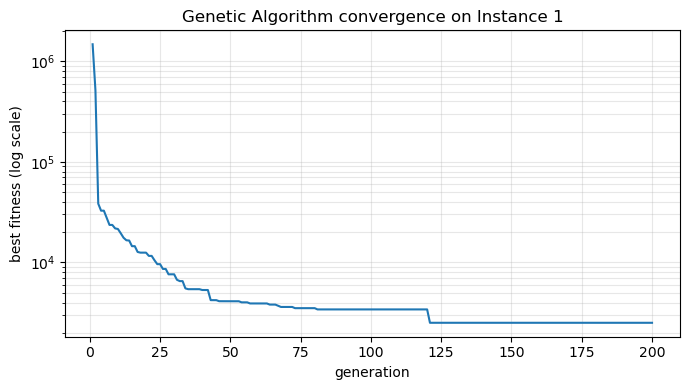

In [17]:
import os

best_mat, best_fit, history = run_ga(inst1, seed=0, pop=100, gens=200)
res = evaluate(best_mat, inst1)

print(f"best fitness (penalty + rho x violations) : {best_fit:.0f}")
print(f"  soft penalty           : {res['penalty']:.0f}")
print(f"  total hard violations  : {sum(res['hard'].values()):.0f}   feasible: {res['feasible']}")
print(f"  first -> last generation: {history[0]:.0f} -> {history[-1]:.0f}")

_, best_fit_again, _ = run_ga(inst1, seed=0, pop=100, gens=200)
print(f"  reproducible (same seed): {best_fit == best_fit_again}")

os.makedirs("results", exist_ok=True)
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(history) + 1), history)
plt.yscale("log")
plt.xlabel("generation")
plt.ylabel("best fitness (log scale)")
plt.title("Genetic Algorithm convergence on Instance 1")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("results/ga_convergence_instance1.png", dpi=200)
plt.show()